<a href="https://colab.research.google.com/github/kanchandhole/Data-Scientist/blob/main/27_marchRegression_2_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Data Science Masters
## Regression Analysis
 R², Adjusted R², MAE, MSE, RMSE, Lasso, Ridge, Regularization

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_regression

plt.style.use('seaborn-v0_8-whitegrid')
COLORS = ['#2E75B6','#C00000','#375623','#7030A0','#ED7D31']
print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


---
## Q1 – R-squared (Coefficient of Determination)
**Explain the concept of R-squared in linear regression models. How is it calculated, and what does it represent?**


### 📖 Theory

**R-squared (R²)**, or the *Coefficient of Determination*, measures the proportion of variance in the
dependent variable that is explained by the independent variable(s).

$$R^2 = 1 - \frac{SS_{res}}{SS_{tot}}$$

Where:
- $SS_{res} = \sum_{i=1}^{n}(y_i - \hat{y}_i)^2$ — **Residual Sum of Squares** (unexplained variance)
- $SS_{tot} = \sum_{i=1}^{n}(y_i - \bar{y})^2$ — **Total Sum of Squares** (total variance)

| R² Value | Interpretation |
|----------|----------------|
| 1.00 | Perfect fit — model explains all variance |
| 0.80–0.99 | Strong fit |
| 0.50–0.79 | Moderate fit |
| 0.00–0.49 | Weak fit |
| < 0 | Model worse than predicting the mean |


         R² Calculation Results
  SS_residual (unexplained) : 51.6214
  SS_total                  : 329.5489
  R² (manual calculation)   : 0.8434
  R² (sklearn)              : 0.8434
  Interpretation            : Model explains 84.3% of variance


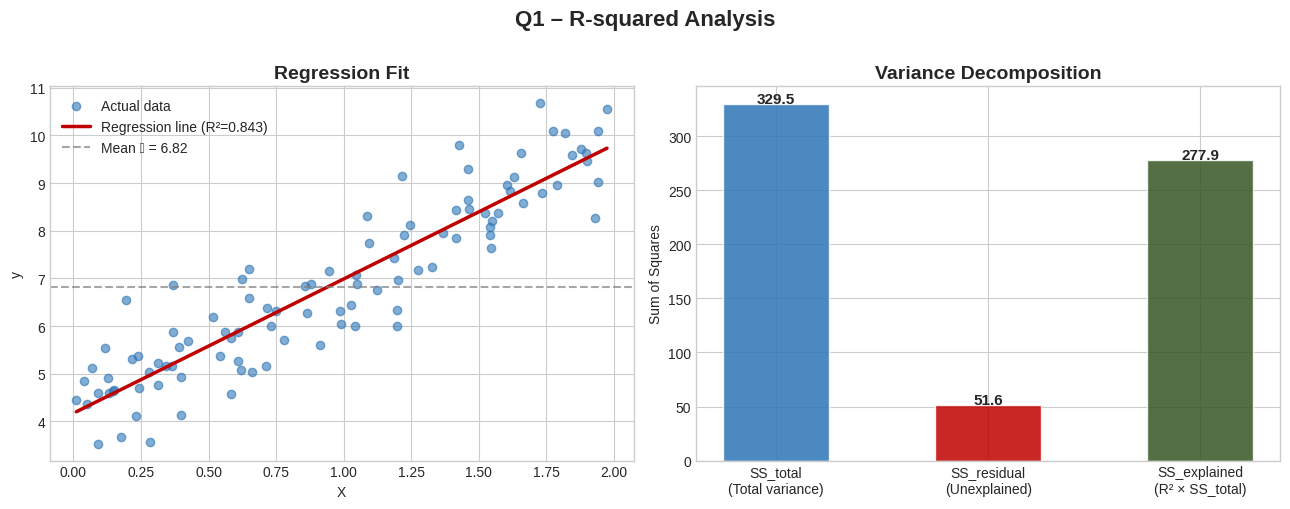

In [2]:
# ── Q1: R-squared Demonstration ────────────────────────────────────────────
np.random.seed(42)
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X.flatten() + np.random.randn(100) * 0.8

model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

SS_res = np.sum((y - y_pred) ** 2)
SS_tot = np.sum((y - np.mean(y)) ** 2)
R2_manual = 1 - (SS_res / SS_tot)
R2_sklearn = r2_score(y, y_pred)

print('=' * 50)
print('         R² Calculation Results')
print('=' * 50)
print(f'  SS_residual (unexplained) : {SS_res:.4f}')
print(f'  SS_total                  : {SS_tot:.4f}')
print(f'  R² (manual calculation)   : {R2_manual:.4f}')
print(f'  R² (sklearn)              : {R2_sklearn:.4f}')
print(f'  Interpretation            : Model explains {R2_sklearn*100:.1f}% of variance')

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter + regression line
axes[0].scatter(X, y, alpha=0.6, color=COLORS[0], label='Actual data')
X_line = np.linspace(X.min(), X.max(), 100).reshape(-1,1)
axes[0].plot(X_line, model.predict(X_line), color=COLORS[1], lw=2.5, label=f'Regression line (R²={R2_sklearn:.3f})')
axes[0].axhline(np.mean(y), color='grey', ls='--', alpha=0.7, label=f'Mean ȳ = {np.mean(y):.2f}')
axes[0].set_title('Regression Fit', fontsize=14, fontweight='bold')
axes[0].set_xlabel('X'); axes[0].set_ylabel('y')
axes[0].legend()

# Variance decomposition bar
bars = axes[1].bar(['SS_total\n(Total variance)', 'SS_residual\n(Unexplained)', 'SS_explained\n(R² × SS_total)'],
                    [SS_tot, SS_res, SS_tot - SS_res],
                    color=[COLORS[0], COLORS[1], COLORS[2]], alpha=0.85, edgecolor='white', width=0.5)
for bar, val in zip(bars, [SS_tot, SS_res, SS_tot - SS_res]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.1f}',
                 ha='center', fontweight='bold', fontsize=11)
axes[1].set_title('Variance Decomposition', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Sum of Squares')

plt.suptitle('Q1 – R-squared Analysis', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## Q2 – Adjusted R-squared
**Define adjusted R-squared and explain how it differs from the regular R-squared.**


### 📖 Theory

**Adjusted R²** penalizes the addition of unnecessary predictors. Unlike R², it *decreases* when a
predictor doesn't improve the model meaningfully.

$$\text{Adjusted } R^2 = 1 - \frac{(1 - R^2)(n - 1)}{n - k - 1}$$

Where **n** = number of observations, **k** = number of predictors.

| Aspect | R² | Adjusted R² |
|--------|-----|-------------|
| Effect of adding predictors | Always ↑ or stays same | ↑ only if predictor adds value |
| Penalization | None | Penalizes for extra predictors |
| Best for | Simple / single-variable models | Multiple regression |


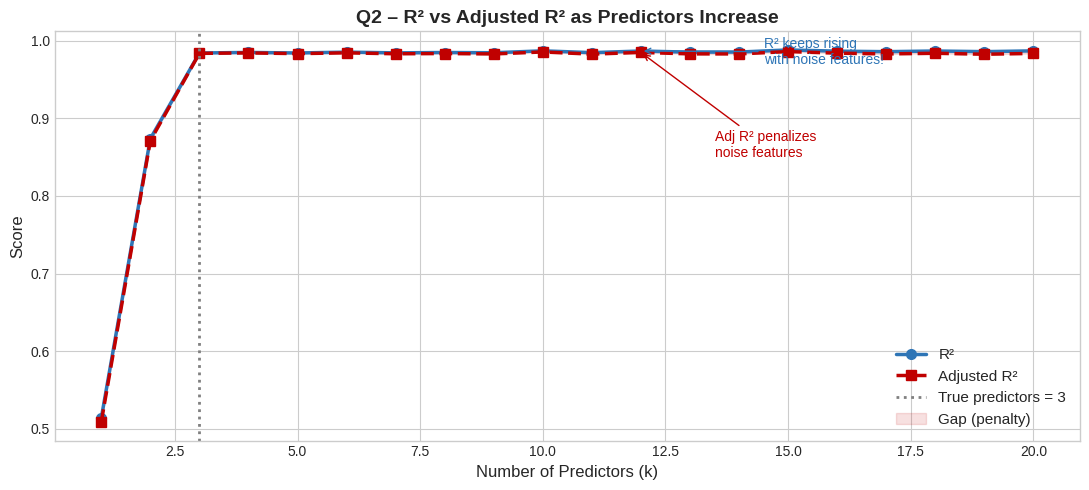

At k=3  → R²=0.9842, Adj R²=0.9837
At k=20 → R²=0.9869, Adj R²=0.9836


In [3]:
# ── Q2: R² vs Adjusted R² with increasing predictors ──────────────────────
np.random.seed(42)
n_samples = 100
# True signal from only 3 features
X_true = np.random.randn(n_samples, 3)
y = 3*X_true[:,0] + 2*X_true[:,1] - X_true[:,2] + np.random.randn(n_samples)*0.5

r2_list, adj_r2_list, k_list = [], [], []

for k in range(1, 21):
    # Add random noise features beyond k=3
    X_noise = np.random.randn(n_samples, max(0, k-3))
    X_use = np.hstack([X_true[:, :min(k,3)], X_noise])

    m = LinearRegression().fit(X_use, y)
    y_p = m.predict(X_use)
    r2 = r2_score(y, y_p)
    adj_r2 = 1 - (1 - r2) * (n_samples - 1) / (n_samples - k - 1)
    r2_list.append(r2)
    adj_r2_list.append(adj_r2)
    k_list.append(k)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(k_list, r2_list, 'o-', color=COLORS[0], lw=2.5, ms=7, label='R²')
ax.plot(k_list, adj_r2_list, 's--', color=COLORS[1], lw=2.5, ms=7, label='Adjusted R²')
ax.axvline(3, color='grey', ls=':', lw=2, label='True predictors = 3')
ax.fill_between(k_list, r2_list, adj_r2_list, alpha=0.12, color=COLORS[1], label='Gap (penalty)')
ax.set_xlabel('Number of Predictors (k)', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Q2 – R² vs Adjusted R² as Predictors Increase', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.annotate('R² keeps rising\nwith noise features!', xy=(12, r2_list[11]),
             xytext=(14.5, 0.97), fontsize=10, color=COLORS[0],
             arrowprops=dict(arrowstyle='->', color=COLORS[0]))
ax.annotate('Adj R² penalizes\nnoise features', xy=(12, adj_r2_list[11]),
             xytext=(13.5, 0.85), fontsize=10, color=COLORS[1],
             arrowprops=dict(arrowstyle='->', color=COLORS[1]))
plt.tight_layout()
plt.show()
print(f'At k=3  → R²={r2_list[2]:.4f}, Adj R²={adj_r2_list[2]:.4f}')
print(f'At k=20 → R²={r2_list[19]:.4f}, Adj R²={adj_r2_list[19]:.4f}')

---
## Q3 – When to Use Adjusted R-squared?


### 📖 Answer

Use **Adjusted R²** in the following situations:

1. **Multiple Regression** – When there are 2 or more predictors
2. **Model Comparison** – Comparing models with *different numbers* of predictors
3. **Feature Selection** – During stepwise or regularized feature selection
4. **Avoiding Overfitting** – Prevents choosing overly complex models

> **Rule of thumb:** Simple linear regression (1 predictor) → R² is fine.  
> Multiple regression (2+ predictors) → always report **Adjusted R²**.


In [4]:
# ── Q3: Which metric to trust for model selection ──────────────────────────
np.random.seed(0)
n = 80
X_base = np.random.randn(n, 5)
y = 2*X_base[:,0] - X_base[:,1] + 0.5*X_base[:,2] + np.random.randn(n)

results = []
for k in [1, 2, 3, 5, 8, 12, 20]:
    Xk = np.hstack([X_base[:, :min(k,5)], np.random.randn(n, max(0, k-5))])
    yp = LinearRegression().fit(Xk, y).predict(Xk)
    r2 = r2_score(y, yp)
    adj = 1 - (1-r2)*(n-1)/(n-k-1)
    results.append({'Predictors (k)': k, 'R²': round(r2,4), 'Adjusted R²': round(adj,4),
                    'Recommend': 'Adjusted R²' if k > 1 else 'R² or Adj R²'})

df = pd.DataFrame(results)
print('\nModel Selection Table — R² vs Adjusted R²')
print('=' * 62)
print(df.to_string(index=False))
print('\n✅ Adjusted R² correctly penalizes models with irrelevant features (k > 5)')


Model Selection Table — R² vs Adjusted R²
 Predictors (k)     R²  Adjusted R²    Recommend
              1 0.6352       0.6305 R² or Adj R²
              2 0.7815       0.7758  Adjusted R²
              3 0.8370       0.8306  Adjusted R²
              5 0.8402       0.8294  Adjusted R²
              8 0.8407       0.8227  Adjusted R²
             12 0.8579       0.8325  Adjusted R²
             20 0.8676       0.8227  Adjusted R²

✅ Adjusted R² correctly penalizes models with irrelevant features (k > 5)


---
## Q4 – RMSE, MSE, and MAE
**What are RMSE, MSE, and MAE? How are they calculated, and what do they represent?**


### 📖 Theory

| Metric | Formula | Units | Outlier Sensitivity |
|--------|---------|-------|---------------------|
| **MAE** | $\frac{1}{n}\sum|y_i - \hat{y}_i|$ | Same as target | Low |
| **MSE** | $\frac{1}{n}\sum(y_i - \hat{y}_i)^2$ | Squared | High |
| **RMSE** | $\sqrt{\frac{1}{n}\sum(y_i - \hat{y}_i)^2}$ | Same as target | High |

- **MAE** – Average absolute deviation. Treats all errors equally.
- **MSE** – Penalizes large errors heavily (squaring). Differentiable everywhere.
- **RMSE** – Same units as target. Like MSE but interpretable on original scale.


       Regression Error Metrics
  MAE    =    9.409   [mean(|errors|)]
  MSE    =  251.807   [mean(errors²)]
  RMSE   =   15.868   [sqrt(MSE)]


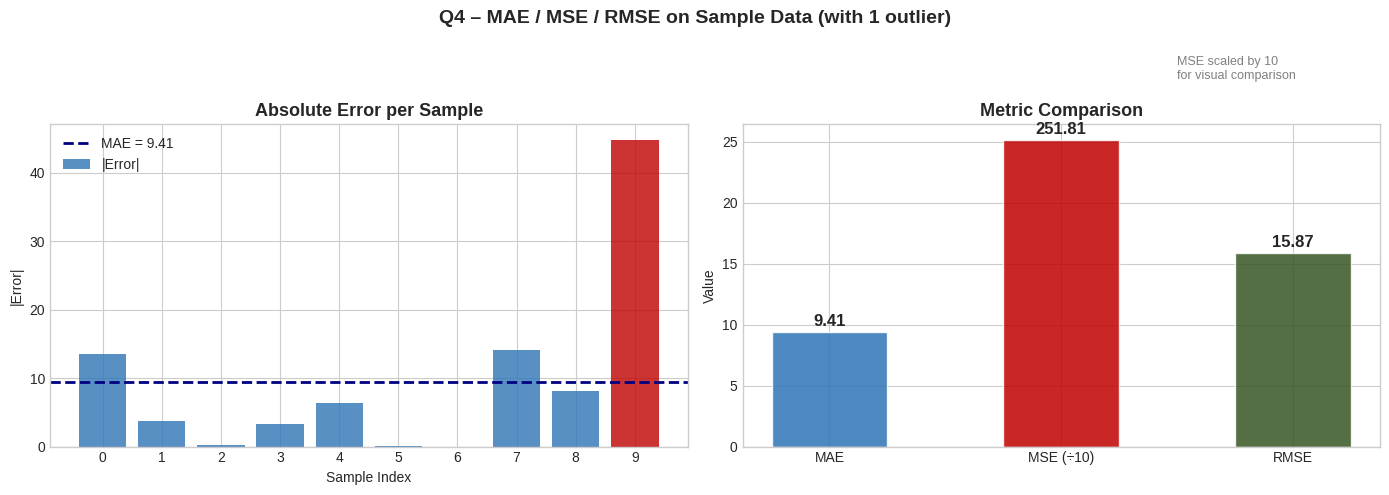

In [5]:
# ── Q4: Compute and visualize MAE, MSE, RMSE ───────────────────────────────
np.random.seed(7)
y_true = np.array([10, 20, 30, 40, 50, 60, 70, 80, 90, 100], dtype=float)
y_pred = y_true + np.random.randn(10) * 8
y_pred[9] += 40   # inject one large outlier

errors = y_true - y_pred
MAE  = np.mean(np.abs(errors))
MSE  = np.mean(errors**2)
RMSE = np.sqrt(MSE)

print('='*48)
print('       Regression Error Metrics')
print('='*48)
for label, val, formula in [
    ('MAE',  MAE,  'mean(|errors|)'),
    ('MSE',  MSE,  'mean(errors²)'),
    ('RMSE', RMSE, 'sqrt(MSE)')]:
    print(f'  {label:<6} = {val:8.3f}   [{formula}]')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Error contributions
x_idx = np.arange(len(y_true))
axes[0].bar(x_idx, np.abs(errors), color=[COLORS[1] if abs(e)>25 else COLORS[0] for e in errors],
            alpha=0.8, label='|Error|')
axes[0].axhline(MAE, color='navy', ls='--', lw=2, label=f'MAE = {MAE:.2f}')
axes[0].set_title('Absolute Error per Sample', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Sample Index'); axes[0].set_ylabel('|Error|')
axes[0].legend(); axes[0].set_xticks(x_idx)

# Metrics comparison
metrics = ['MAE', 'MSE (÷10)', 'RMSE']
values  = [MAE, MSE/10, RMSE]
bars = axes[1].bar(metrics, values, color=COLORS[:3], alpha=0.85, width=0.5, edgecolor='white')
for bar, val, orig in zip(bars, values, [MAE, MSE, RMSE]):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, f'{orig:.2f}',
                 ha='center', fontweight='bold', fontsize=12)
axes[1].set_title('Metric Comparison', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Value')
axes[1].annotate('MSE scaled by 10\nfor visual comparison', xy=(1, values[1]),
                  xytext=(1.5, values[1]+5), fontsize=9, color='grey')

plt.suptitle('Q4 – MAE / MSE / RMSE on Sample Data (with 1 outlier)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Q5 – Advantages and Disadvantages of RMSE, MSE, MAE


### 📖 Summary Table

| Metric | ✅ Advantages | ❌ Disadvantages |
|--------|--------------|------------------|
| **MAE** | Robust to outliers; easy to interpret; same units | Not differentiable at 0; weights all errors equally |
| **MSE** | Differentiable; penalizes large errors; loss-friendly | Squared units; very sensitive to outliers |
| **RMSE** | Same units as target; penalizes large errors | Still outlier-sensitive; slightly harder to explain |


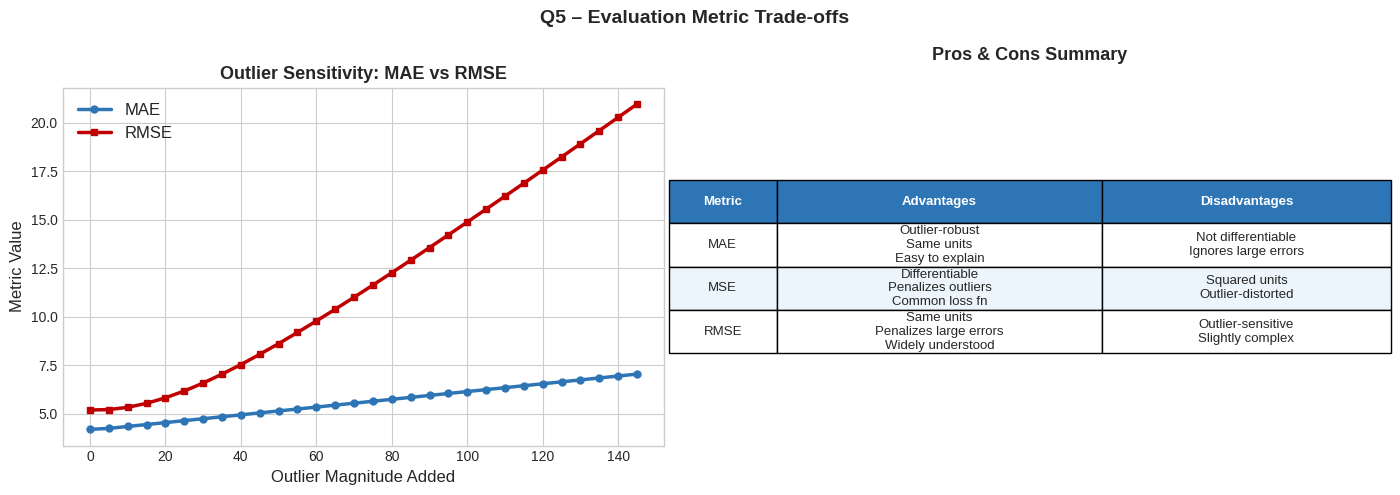

In [6]:
# ── Q5: Impact of outliers on MAE vs RMSE ──────────────────────────────────
np.random.seed(3)
y_true_base = np.linspace(10, 100, 50)
y_pred_base = y_true_base + np.random.randn(50) * 5

outlier_magnitudes = np.arange(0, 150, 5)
mae_vals, rmse_vals = [], []

for mag in outlier_magnitudes:
    yp = y_pred_base.copy()
    yp[-1] += mag   # increase outlier severity
    mae_vals.append(mean_absolute_error(y_true_base, yp))
    rmse_vals.append(np.sqrt(mean_squared_error(y_true_base, yp)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sensitivity plot
axes[0].plot(outlier_magnitudes, mae_vals,  'o-', color=COLORS[0], lw=2.5, ms=5, label='MAE')
axes[0].plot(outlier_magnitudes, rmse_vals, 's-', color=COLORS[1], lw=2.5, ms=5, label='RMSE')
axes[0].set_xlabel('Outlier Magnitude Added', fontsize=12)
axes[0].set_ylabel('Metric Value', fontsize=12)
axes[0].set_title('Outlier Sensitivity: MAE vs RMSE', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=12)

# Pros/cons as annotated table
axes[1].axis('off')
table_data = [
    ['Metric', 'Advantages', 'Disadvantages'],
    ['MAE', 'Outlier-robust\nSame units\nEasy to explain', 'Not differentiable\nIgnores large errors'],
    ['MSE', 'Differentiable\nPenalizes outliers\nCommon loss fn', 'Squared units\nOutlier-distorted'],
    ['RMSE', 'Same units\nPenalizes large errors\nWidely understood', 'Outlier-sensitive\nSlightly complex'],
]
t = axes[1].table(cellText=table_data[1:], colLabels=table_data[0],
                   cellLoc='center', loc='center',
                   colWidths=[0.15, 0.45, 0.4])
t.auto_set_font_size(False)
t.set_fontsize(9.5)
t.scale(1.2, 2.8)
for (r,c), cell in t.get_celld().items():
    if r == 0:
        cell.set_facecolor('#2E75B6'); cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#EBF5FB')
axes[1].set_title('Pros & Cons Summary', fontsize=13, fontweight='bold', pad=20)

plt.suptitle('Q5 – Evaluation Metric Trade-offs', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Q6 – Lasso vs Ridge Regularization
**Explain Lasso regularization. How does it differ from Ridge, and when is it more appropriate?**


### 📖 Theory

| Property | **Lasso (L1)** | **Ridge (L2)** |
|----------|----------------|----------------|
| Penalty | $\lambda \sum|\beta_j|$ | $\lambda \sum\beta_j^2$ |
| Feature selection | ✅ Sets some β = 0 (sparse) | ❌ Shrinks but never zero |
| Best when | Many irrelevant features | All features are informative |
| Geometry | Diamond constraint | Circle constraint |
| Multicollinearity | Picks one, drops others | Distributes weight |

**Lasso Cost:** $\sum(y_i - \hat{y}_i)^2 + \lambda\sum|\beta_j|$  
**Ridge Cost:** $\sum(y_i - \hat{y}_i)^2 + \lambda\sum\beta_j^2$


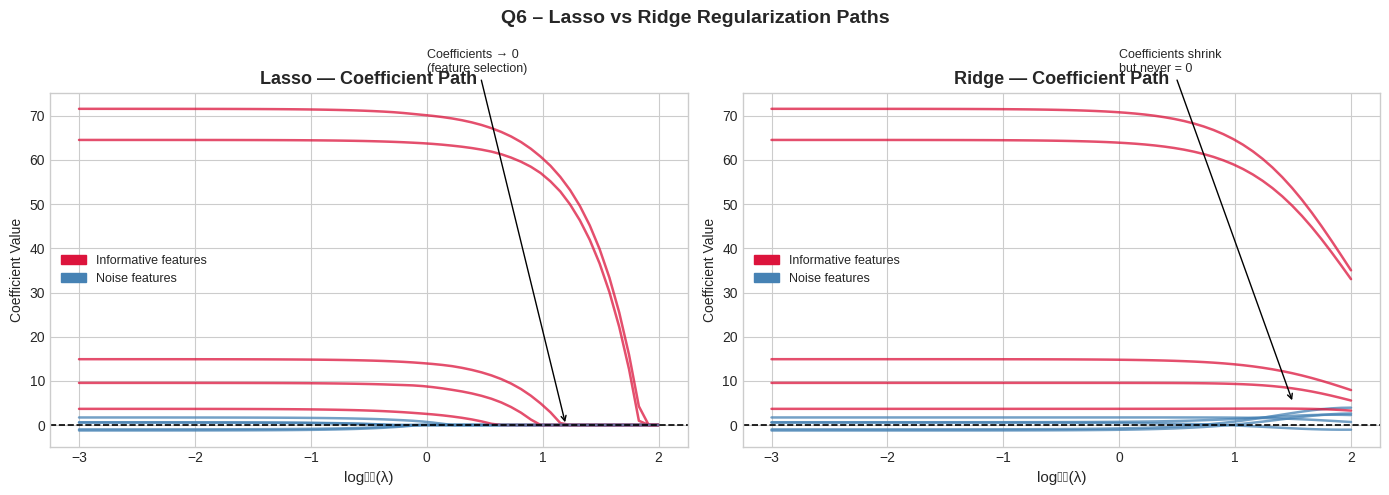

In [7]:
# ── Q6: Lasso vs Ridge coefficient paths ────────────────────────────────────
from sklearn.linear_model import lasso_path, ridge_regression

np.random.seed(42)
X_reg, y_reg, true_coef = make_regression(n_samples=100, n_features=10,
                                            n_informative=5, noise=10,
                                            coef=True, random_state=42)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_reg)

alphas = np.logspace(-3, 2, 60)
lasso_coefs = np.array([Lasso(alpha=a, max_iter=10000).fit(X_scaled, y_reg).coef_ for a in alphas])
ridge_coefs = np.array([Ridge(alpha=a).fit(X_scaled, y_reg).coef_ for a in alphas])

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

for i in range(lasso_coefs.shape[1]):
    axes[0].plot(np.log10(alphas), lasso_coefs[:, i], lw=1.8,
                 color='crimson' if abs(true_coef[i]) > 0 else 'steelblue', alpha=0.75)
axes[0].axhline(0, color='black', lw=1.2, ls='--')
axes[0].set_title('Lasso — Coefficient Path', fontsize=13, fontweight='bold')
axes[0].set_xlabel('log₁₀(λ)', fontsize=11); axes[0].set_ylabel('Coefficient Value')
axes[0].annotate('Coefficients → 0\n(feature selection)', xy=(1.2, 0), xytext=(0, 80),
                  fontsize=9, arrowprops=dict(arrowstyle='->', color='black'))

for i in range(ridge_coefs.shape[1]):
    axes[1].plot(np.log10(alphas), ridge_coefs[:, i], lw=1.8,
                 color='crimson' if abs(true_coef[i]) > 0 else 'steelblue', alpha=0.75)
axes[1].axhline(0, color='black', lw=1.2, ls='--')
axes[1].set_title('Ridge — Coefficient Path', fontsize=13, fontweight='bold')
axes[1].set_xlabel('log₁₀(λ)', fontsize=11); axes[1].set_ylabel('Coefficient Value')
axes[1].annotate('Coefficients shrink\nbut never = 0', xy=(1.5, 5), xytext=(0, 80),
                  fontsize=9, arrowprops=dict(arrowstyle='->', color='black'))

red_p = mpatches.Patch(color='crimson', label='Informative features')
blue_p = mpatches.Patch(color='steelblue', label='Noise features')
for ax in axes:
    ax.legend(handles=[red_p, blue_p], fontsize=9)

plt.suptitle('Q6 – Lasso vs Ridge Regularization Paths', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Q7 – How Regularized Models Prevent Overfitting
**Explain with an example.**


### 📖 Theory

Overfitting happens when a model learns noise rather than signal — high training accuracy, poor test accuracy.

**Regularization** adds a complexity penalty to the cost function:
- Constrains coefficient magnitudes
- Reduces model variance at cost of small bias (bias-variance trade-off)
- Optimal λ is found via **cross-validation**

```
High λ  → Stronger penalty → Simpler model → Higher bias, lower variance
Low λ   → Weaker penalty  → Complex model → Lower bias, higher variance
```



Overfitting Comparison Table
              Train RMSE  Test RMSE  Non-zero coefs  Overfit Gap
OLS (No Reg)        4.58     152.54            40.0       147.96
Ridge (λ=10)       19.01     124.22            40.0       105.21
Lasso (λ=1)         9.16     138.44            20.0       129.28


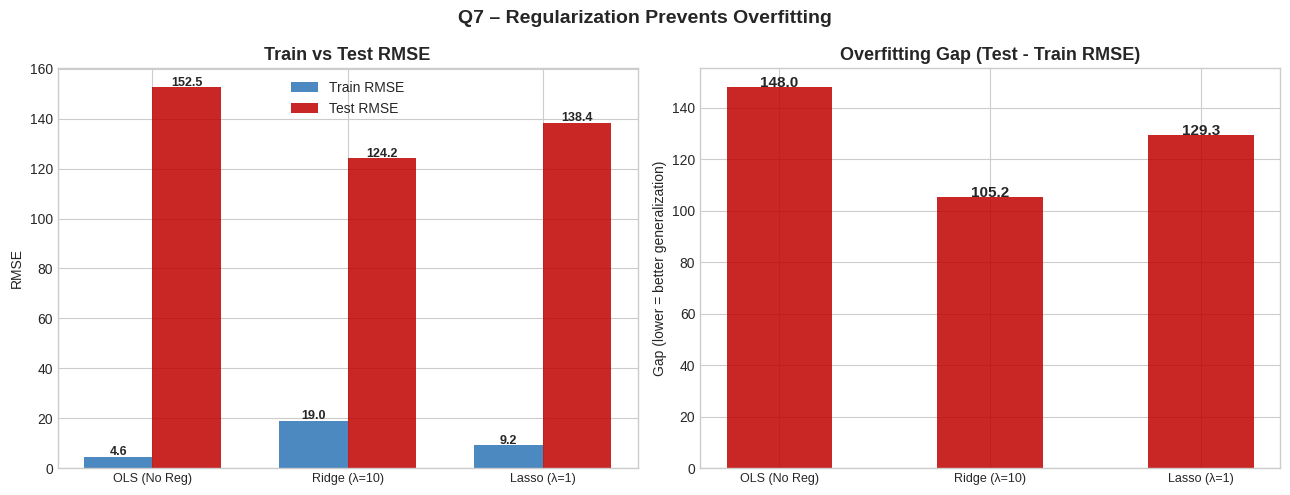

In [8]:
# ── Q7: Overfitting demo – OLS vs Ridge vs Lasso ────────────────────────────
np.random.seed(42)
n_train, n_test = 50, 200

X_train, y_train, coef_true = make_regression(
    n_samples=n_train, n_features=40, n_informative=5,
    noise=15, coef=True, random_state=42)
X_test, y_test = make_regression(
    n_samples=n_test, n_features=40, n_informative=5,
    noise=15, random_state=99)[:2]

sc = StandardScaler()
X_tr = sc.fit_transform(X_train)
X_te = sc.transform(X_test)

results = {}
for name, model in [('OLS (No Reg)', LinearRegression()),
                     ('Ridge (λ=10)', Ridge(alpha=10)),
                     ('Lasso (λ=1)',  Lasso(alpha=1, max_iter=5000))]:
    model.fit(X_tr, y_train)
    tr_rmse = np.sqrt(mean_squared_error(y_train, model.predict(X_tr)))
    te_rmse = np.sqrt(mean_squared_error(y_test,  model.predict(X_te)))
    nonzero = np.sum(np.abs(model.coef_) > 0.01)
    results[name] = {'Train RMSE': tr_rmse, 'Test RMSE': te_rmse,
                     'Non-zero coefs': nonzero, 'Overfit Gap': te_rmse - tr_rmse}

df_res = pd.DataFrame(results).T.round(2)
print('\nOverfitting Comparison Table')
print('=' * 65)
print(df_res.to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

models_list = list(results.keys())
train_r = [results[m]['Train RMSE'] for m in models_list]
test_r  = [results[m]['Test RMSE'] for m in models_list]
x = np.arange(len(models_list))
w = 0.35

axes[0].bar(x - w/2, train_r, w, label='Train RMSE', color=COLORS[0], alpha=0.85)
axes[0].bar(x + w/2, test_r,  w, label='Test RMSE',  color=COLORS[1], alpha=0.85)
for i, (tr, te) in enumerate(zip(train_r, test_r)):
    axes[0].text(i-w/2, tr+0.5, f'{tr:.1f}', ha='center', fontsize=9, fontweight='bold')
    axes[0].text(i+w/2, te+0.5, f'{te:.1f}', ha='center', fontsize=9, fontweight='bold')
axes[0].set_xticks(x); axes[0].set_xticklabels(models_list, fontsize=9)
axes[0].set_title('Train vs Test RMSE', fontsize=13, fontweight='bold')
axes[0].set_ylabel('RMSE'); axes[0].legend()

# Overfitting gap
gaps = [results[m]['Overfit Gap'] for m in models_list]
bars = axes[1].bar(models_list, gaps,
                    color=[COLORS[1] if g > 5 else COLORS[2] for g in gaps],
                    alpha=0.85, width=0.5)
for bar, g in zip(bars, gaps):
    axes[1].text(bar.get_x()+bar.get_width()/2, g+0.3, f'{g:.1f}',
                 ha='center', fontweight='bold', fontsize=11)
axes[1].set_title('Overfitting Gap (Test - Train RMSE)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Gap (lower = better generalization)')
axes[1].set_xticklabels(models_list, fontsize=9)

plt.suptitle('Q7 – Regularization Prevents Overfitting', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Q8 – Limitations of Regularized Linear Models


### 📖 Limitations

1. **Linearity Assumption** – Regularization cannot fix non-linear relationships
2. **Hyperparameter Tuning** – λ must be chosen carefully via cross-validation
3. **Feature Scaling Required** – Coefficients are scale-sensitive; must standardize
4. **Lasso Instability** – With correlated features, Lasso arbitrarily drops some
5. **Cannot Model Complex Patterns** – Tree-based or neural models may outperform
6. **May Underfit with High λ** – Excessive penalty introduces too much bias


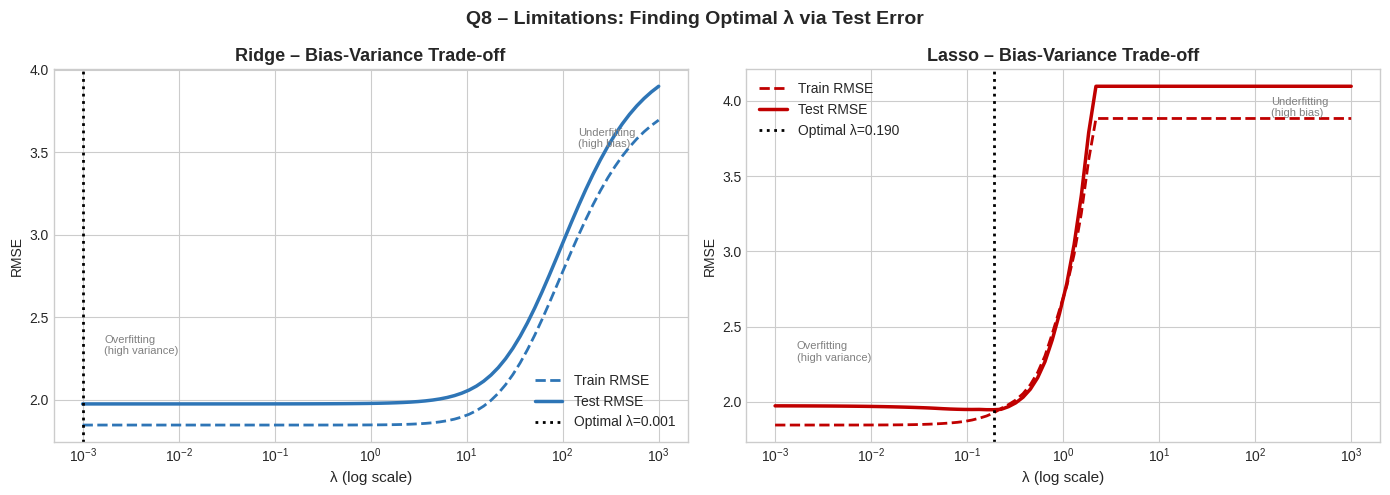

Optimal Ridge λ: 0.0010 | Optimal Lasso λ: 0.1899


In [9]:
# ── Q8: Demonstrating the λ trade-off (bias vs variance) ───────────────────
np.random.seed(42)
n = 120
X8 = np.random.randn(n, 10)
y8 = 3*X8[:,0] + 2*X8[:,1] - X8[:,2] + np.random.randn(n)*2

X8_tr, X8_te, y8_tr, y8_te = train_test_split(X8, y8, test_size=0.3, random_state=1)
sc8 = StandardScaler()
X8_tr = sc8.fit_transform(X8_tr)
X8_te = sc8.transform(X8_te)

lambdas = np.logspace(-3, 3, 80)
ridge_tr, ridge_te = [], []
lasso_tr, lasso_te = [], []

for lam in lambdas:
    r = Ridge(alpha=lam).fit(X8_tr, y8_tr)
    ridge_tr.append(np.sqrt(mean_squared_error(y8_tr, r.predict(X8_tr))))
    ridge_te.append(np.sqrt(mean_squared_error(y8_te, r.predict(X8_te))))
    l = Lasso(alpha=lam, max_iter=5000).fit(X8_tr, y8_tr)
    lasso_tr.append(np.sqrt(mean_squared_error(y8_tr, l.predict(X8_tr))))
    lasso_te.append(np.sqrt(mean_squared_error(y8_te, l.predict(X8_te))))

opt_ridge_lam = lambdas[np.argmin(ridge_te)]
opt_lasso_lam = lambdas[np.argmin(lasso_te)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, tr, te, lams_opt, title, color in [
    (axes[0], ridge_tr, ridge_te, opt_ridge_lam, 'Ridge', COLORS[0]),
    (axes[1], lasso_tr, lasso_te, opt_lasso_lam, 'Lasso', COLORS[1])]:
    ax.semilogx(lambdas, tr, '--', color=color, lw=2, label='Train RMSE')
    ax.semilogx(lambdas, te, '-',  color=color, lw=2.5, label='Test RMSE')
    ax.axvline(lams_opt, color='black', ls=':', lw=2, label=f'Optimal λ={lams_opt:.3f}')
    ax.set_xlabel('λ (log scale)', fontsize=11); ax.set_ylabel('RMSE')
    ax.set_title(f'{title} – Bias-Variance Trade-off', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.annotate('Underfitting\n(high bias)', xy=(lambdas[-5], te[-5]),
                 xytext=(lambdas[-12], te[-5]-0.2), fontsize=8, color='gray')
    ax.annotate('Overfitting\n(high variance)', xy=(lambdas[3], te[3]),
                 xytext=(lambdas[3], te[3]+0.3), fontsize=8, color='gray')

plt.suptitle('Q8 – Limitations: Finding Optimal λ via Test Error', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Optimal Ridge λ: {opt_ridge_lam:.4f} | Optimal Lasso λ: {opt_lasso_lam:.4f}')

---
## Q9 – Model A (RMSE=10) vs Model B (MAE=8): Which is better?


### 📖 Answer

**You cannot directly compare RMSE=10 and MAE=8** — they are different metrics measured on potentially
different scales and with different outlier sensitivity.

| Scenario | Preferred Metric | Decision |
|----------|-----------------|----------|
| Large errors are very costly | RMSE | Compare Model A's RMSE to baseline |
| All errors equally important | MAE | Use Model B's metric for comparison |
| Dataset has outliers | MAE | More robust |
| Need same-unit interpretability | RMSE or MAE | Compute both on same test set |

**Correct approach:** Compute **both** metrics on **both** models using the **same test set**.



Fair Comparison — Same Test Set, Both Metrics
                       RMSE    MAE     R²
Model A (5 features)  8.872  7.049  0.078
Model B (2 features)  8.776  6.944  0.098


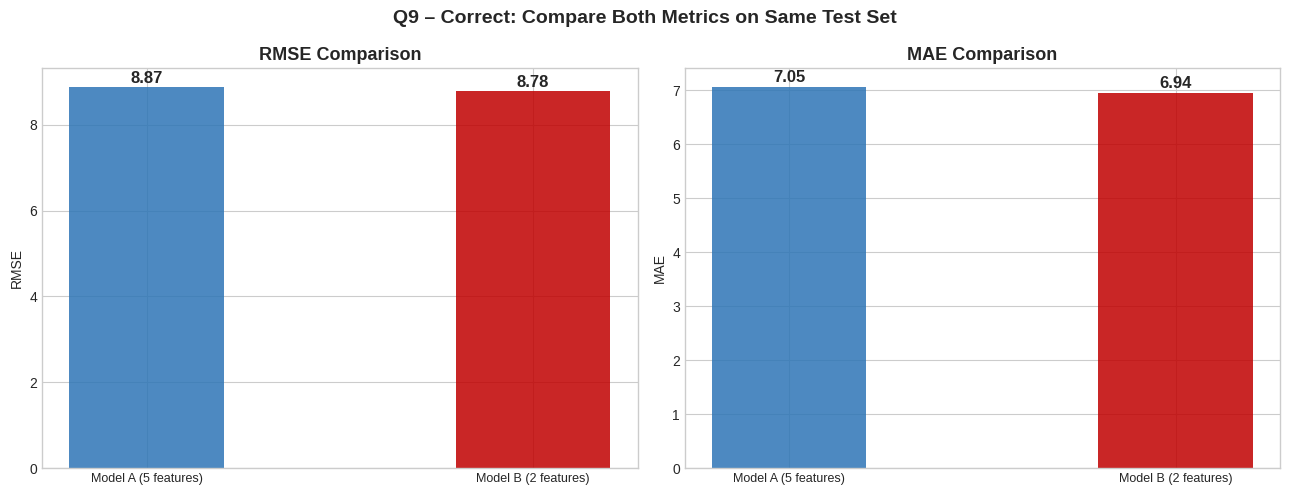


⚠  Conclusion: Never compare RMSE of one model to MAE of another.
✅  Always compute both metrics on both models using an identical test set.


In [10]:
# ── Q9: Why cross-metric comparison is misleading ───────────────────────────
np.random.seed(42)
n9 = 200
X9 = np.random.randn(n9, 5)
y9 = 3*X9[:,0] + 2*X9[:,1] + np.random.randn(n9)*8

X9_tr, X9_te, y9_tr, y9_te = train_test_split(X9, y9, test_size=0.3, random_state=0)

# Model A – trained on all 5 features
mA = LinearRegression().fit(X9_tr, y9_tr)
# Model B – trained on only 2 features (simulating a simpler model)
mB = LinearRegression().fit(X9_tr[:, :2], y9_tr)

yA = mA.predict(X9_te)
yB = mB.predict(X9_te[:, :2])

metrics = {
    'Model A (5 features)': {
        'RMSE': np.sqrt(mean_squared_error(y9_te, yA)),
        'MAE':  mean_absolute_error(y9_te, yA),
        'R²':   r2_score(y9_te, yA)
    },
    'Model B (2 features)': {
        'RMSE': np.sqrt(mean_squared_error(y9_te, yB)),
        'MAE':  mean_absolute_error(y9_te, yB),
        'R²':   r2_score(y9_te, yB)
    }
}
df9 = pd.DataFrame(metrics).T.round(3)
print('\nFair Comparison — Same Test Set, Both Metrics')
print('=' * 52)
print(df9.to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, metric in zip(axes, ['RMSE', 'MAE']):
    vals = [metrics[m][metric] for m in metrics]
    bars = ax.bar(list(metrics.keys()), vals, color=COLORS[:2], alpha=0.85, width=0.4)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, v+0.1, f'{v:.2f}',
                ha='center', fontweight='bold', fontsize=12)
    ax.set_title(f'{metric} Comparison', fontsize=13, fontweight='bold')
    ax.set_ylabel(metric)
    ax.set_xticklabels(list(metrics.keys()), fontsize=9)

plt.suptitle('Q9 – Correct: Compare Both Metrics on Same Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print('\n⚠  Conclusion: Never compare RMSE of one model to MAE of another.')
print('✅  Always compute both metrics on both models using an identical test set.')

---
## Q10 – Ridge (λ=0.1) vs Lasso (λ=0.5): Which is better?


### 📖 Answer

| Property | Model A – Ridge (λ=0.1) | Model B – Lasso (λ=0.5) |
|----------|------------------------|-------------------------|
| Penalty type | L2 (squared) | L1 (absolute) |
| Strength | Weak | Moderate |
| Feature selection | ❌ No | ✅ Yes (sparse model) |
| Best when | All features informative | Many features irrelevant |

**Decision depends on context** — evaluate both on the same test set using the same metric.  
Use **cross-validation** to tune λ independently for each.



Ridge (λ=0.1) vs Lasso (λ=0.5) — Full Comparison
                                 Ridge      Lasso
  RMSE                          11.223     10.322
  MAE                            8.830      8.124
  R²                             0.995      0.995
  Non-zero coefficients             20         13


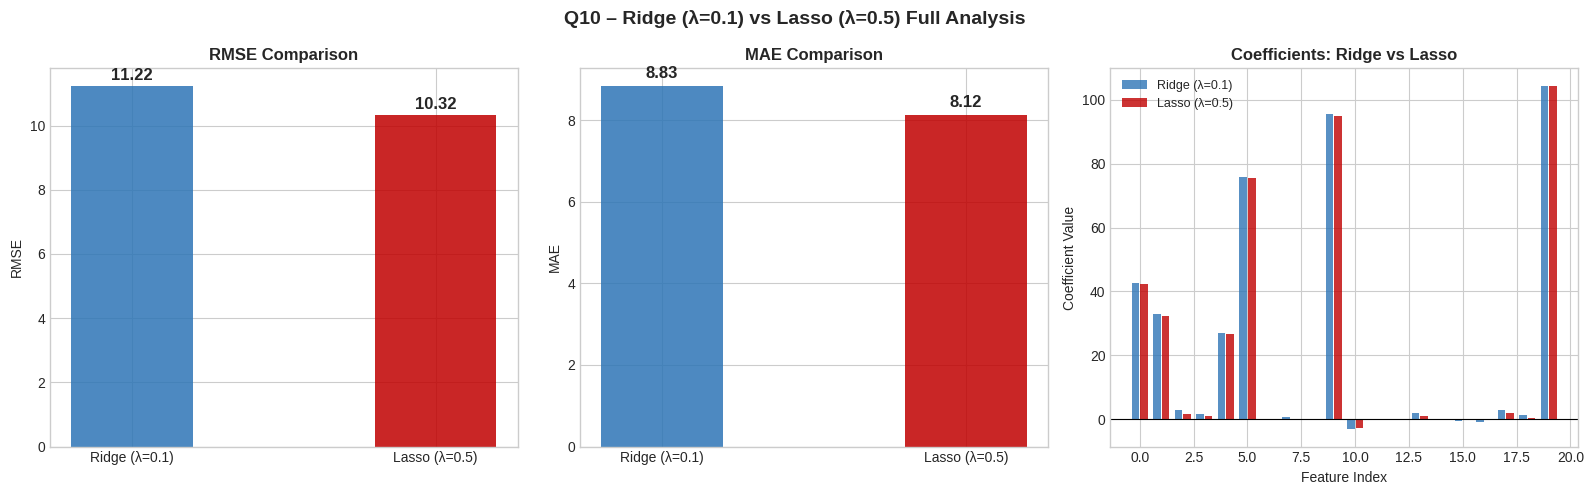


✅  On this dataset, Lasso achieves lower RMSE.
   Lasso uses only 13/20 features → sparser, more interpretable model.
   Trade-off: Lasso = interpretability; Ridge = stability with correlated features.


In [11]:
# ── Q10: Ridge (λ=0.1) vs Lasso (λ=0.5) side-by-side ──────────────────────
np.random.seed(42)
X10, y10, coef10 = make_regression(n_samples=150, n_features=20,
                                     n_informative=6, noise=10,
                                     coef=True, random_state=42)
X10_tr, X10_te, y10_tr, y10_te = train_test_split(X10, y10, test_size=0.3, random_state=7)
sc10 = StandardScaler()
X10_tr = sc10.fit_transform(X10_tr)
X10_te = sc10.transform(X10_te)

ridge_m = Ridge(alpha=0.1).fit(X10_tr, y10_tr)
lasso_m = Lasso(alpha=0.5, max_iter=10000).fit(X10_tr, y10_tr)

r_rmse = np.sqrt(mean_squared_error(y10_te, ridge_m.predict(X10_te)))
l_rmse = np.sqrt(mean_squared_error(y10_te, lasso_m.predict(X10_te)))
r_mae  = mean_absolute_error(y10_te, ridge_m.predict(X10_te))
l_mae  = mean_absolute_error(y10_te, lasso_m.predict(X10_te))
r_r2   = r2_score(y10_te, ridge_m.predict(X10_te))
l_r2   = r2_score(y10_te, lasso_m.predict(X10_te))
r_nz   = np.sum(np.abs(ridge_m.coef_) > 0.01)
l_nz   = np.sum(np.abs(lasso_m.coef_) > 0.01)

print('\nRidge (λ=0.1) vs Lasso (λ=0.5) — Full Comparison')
print('=' * 56)
print(f'  {"":25} {"Ridge":>10} {"Lasso":>10}')
print(f'  {"RMSE":25} {r_rmse:>10.3f} {l_rmse:>10.3f}')
print(f'  {"MAE":25} {r_mae:>10.3f} {l_mae:>10.3f}')
print(f'  {"R²":25} {r_r2:>10.3f} {l_r2:>10.3f}')
print(f'  {"Non-zero coefficients":25} {r_nz:>10} {l_nz:>10}')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# RMSE & MAE bar comparison
for ax, metric, vals in [
    (axes[0], 'RMSE', [r_rmse, l_rmse]),
    (axes[1], 'MAE',  [r_mae, l_mae])]:
    bars = ax.bar(['Ridge (λ=0.1)', 'Lasso (λ=0.5)'], vals,
                   color=[COLORS[0], COLORS[1]], alpha=0.85, width=0.4)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, v+0.2, f'{v:.2f}',
                ha='center', fontweight='bold', fontsize=12)
    ax.set_title(f'{metric} Comparison', fontsize=12, fontweight='bold')
    ax.set_ylabel(metric)

# Coefficient plot
feat_idx = np.arange(20)
axes[2].bar(feat_idx - 0.2, ridge_m.coef_, 0.35, color=COLORS[0], alpha=0.8, label='Ridge (λ=0.1)')
axes[2].bar(feat_idx + 0.2, lasso_m.coef_, 0.35, color=COLORS[1], alpha=0.8, label='Lasso (λ=0.5)')
axes[2].axhline(0, color='black', lw=0.8)
axes[2].set_title('Coefficients: Ridge vs Lasso', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Feature Index'); axes[2].set_ylabel('Coefficient Value')
axes[2].legend(fontsize=9)

plt.suptitle('Q10 – Ridge (λ=0.1) vs Lasso (λ=0.5) Full Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

winner = 'Ridge' if r_rmse < l_rmse else 'Lasso'
print(f'\n✅  On this dataset, {winner} achieves lower RMSE.')
print(f'   Lasso uses only {l_nz}/20 features → sparser, more interpretable model.')
print('   Trade-off: Lasso = interpretability; Ridge = stability with correlated features.')